<a href="https://colab.research.google.com/github/Tamar-program/ShardDetector/blob/main/research/EasyOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# The environment was prepared for EasyOCR evaluation (CPU/GPU optional)
!pip install easyocr==1.7.1 rapidfuzz==3.9.6 opencv-python-headless==4.10.0.84

In [16]:
# The libraries required for OCR, preprocessing, timing, and evaluation were imported
import os, time, glob, string, csv
import cv2
import numpy as np
import easyocr
from rapidfuzz.distance import Levenshtein


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# The dataset paths and evaluation parameters were defined
import os, csv, string
IMAGES_DIR = "/content/drive/MyDrive/תמונות בשביל הערכת ביצועים/Crops" # folder of test images
GT_CSV     = "/content/drive/MyDrive/תמונות בשביל הערכת ביצועים/GT/ground_truth.csv"      # CSV with columns: filename,gt_text
LANGS      = ['en']                                # e.g., ['en'], or ['en','he'] if hebrew pack installed
GPU        = False                                 # set True if CUDA available
PSM_HINT   = None                                  # not used in EasyOCR; kept for symmetry
ALLOWED    = string.ascii_uppercase + string.digits  # optional post-filter


In [19]:
# The ground-truth table was loaded into a filename→text mapping
import csv

gt = {}
with open(GT_CSV, newline="", encoding="utf-8-sig") as f:
    for row in csv.DictReader(f):
        gt[row["filename"]] = row["gt_text"]
print("rows loaded:", len(gt))



rows loaded: 489


In [20]:
#Normalize illumination, boost local contrast, and suppress noise so text becomes more legible and OCR is more robust
# Lightweight preprocessing functions were provided (toggleable per experiment)
def preprocess(img_bgr, do_gray=True, do_clahe=True, do_blur=True):
    # A grayscale + CLAHE + mild blur pipeline was applied to enhance text legibility
    out = img_bgr.copy()
    if do_gray:
        out = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)
    if do_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        out = clahe.apply(out)
    if do_blur:
        out = cv2.medianBlur(out, 3)
    return out


In [21]:
# The evaluation metrics were defined: CER, WER, and Levenshtein distance
def levenshtein(a, b):  # edit distance
    return Levenshtein.distance(a, b)

def cer(hyp, ref):
    # The character error rate was computed as edit_distance / len(ref)
    if len(ref) == 0:
        return 0.0 if len(hyp) == 0 else 1.0
    return levenshtein(hyp, ref) / len(ref)

def wer(hyp, ref):
    # The word error rate was computed on whitespace-tokenized strings
    ref_w = ref.split()
    hyp_w = hyp.split()
    if len(ref_w) == 0:
        return 0.0 if len(hyp_w) == 0 else 1.0
    return Levenshtein.distance(" ".join(hyp_w), " ".join(ref_w)) / max(1, len(ref_w))


In [22]:
# The OCR function was defined (with optional allowed-characters post-filtering)
def ocr_easy(img_any, allowed=None):
    # The image was passed to EasyOCR and the best-line hypothesis was returned
    results = reader.readtext(img_any, detail=1, paragraph=True)
    # A naive concatenation of detected fragments was used for a single-string hypothesis
    text = " ".join([t[1] for t in results]).strip()
    if allowed:
        text = "".join([c for c in text if c in allowed or c.isspace()])
    return text, results


In [23]:
# Ensure EasyOCR reader exists before running the loop
if 'reader' not in globals() or reader is None:
    reader = easyocr.Reader(LANGS, gpu=GPU, verbose=False)
print("EasyOCR ready with:", LANGS, "| GPU:", GPU)


EasyOCR ready with: ['en'] | GPU: False


In [14]:
# The dataset was evaluated with timing and metrics; per-image results were collected
from collections import defaultdict
records = []
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.*")))
for p in image_files:
    fname = os.path.basename(p)
    img_bgr = cv2.imread(p)
    if img_bgr is None or fname not in gt:
        continue

    # The image was preprocessed for OCR robustness
    proc = preprocess(img_bgr, do_gray=True, do_clahe=True, do_blur=True)

    # The OCR was timed to compute latency per image
    t0 = time.perf_counter()
    hyp, raw = ocr_easy(proc, allowed=ALLOWED)
    dt = (time.perf_counter() - t0) * 1000.0  # ms

    ref = gt[fname]
    rec = {
        "filename": fname,
        "gt_text": ref,
        "pred_text": hyp,
        "levenshtein": levenshtein(hyp, ref),
        "cer": cer(hyp, ref),
        "wer": wer(hyp, ref),
        "latency_ms": round(dt, 2),
        "chars_gt": len(ref),
        "chars_pred": len(hyp),
    }
    records.append(rec)


In [24]:
# The results were summarized with aggregate statistics for reporting
import pandas as pd
df = pd.DataFrame(records)
summary = {
    "n_images": len(df),
    "avg_CER": df["cer"].mean() if len(df) else None,
    "avg_WER": df["wer"].mean() if len(df) else None,
    "avg_levenshtein": df["levenshtein"].mean() if len(df) else None,
    "avg_latency_ms": df["latency_ms"].mean() if len(df) else None,
}
df.head(8), summary


(                                            filename gt_text pred_text  \
 0  Firefly_broken pieces of old pottery, similor ...                     
 1  Firefly_broken pieces of old pottery, similor ...                     
 2  Firefly_broken pieces of old pottery, similor ...                     
 3  Firefly_broken pieces of old pottery, similor ...                     
 4  Firefly_broken pieces of old pottery, similor ...                     
 5  Firefly_broken pieces of old pottery, similor ...                     
 6  Firefly_broken pieces of old pottery, similor ...                     
 7  Firefly_broken pieces of old pottery, similor ...                     
 
    levenshtein  cer  wer  latency_ms  chars_gt  chars_pred  
 0            0  0.0  0.0     1307.79         0           0  
 1            0  0.0  0.0     1963.12         0           0  
 2            0  0.0  0.0     7466.19         0           0  
 3            0  0.0  0.0     2001.32         0           0  
 4           

In [26]:
# The worst-performing samples were surfaced for qualitative error analysis
df_worst = df.sort_values("cer", ascending=False).head(12)[["filename","gt_text","pred_text","cer","wer","latency_ms"]]
df_worst


,filename,gt_text,pred_text,cer,wer,latency_ms
176,WhatsApp Image 2025-07-13 at 11.01.49_d07f7057...,6,3,2.0,1.000000,1234.50
167,WhatsApp Image 2025-07-13 at 11.00.52_ea9a24ae...,56,,1.0,2.000000,415.91
98,IMG-20250713-WA0040_shard_011_c0.92.jpg,A9656 17 112-1,,1.0,4.666667,441.82
106,IMG-20250713-WA0040_shard_019_c0.89.jpg,A9656 14 144,,1.0,4.000000,402.59
107,IMG-20250713-WA0040_shard_020_c0.88.jpg,A9656 17 149-1,,1.0,4.666667,179.53
100,IMG-20250713-WA0040_shard_013_c0.92.jpg,A9656 17 114-5,,1.0,4.666667,1209.90
206,bright_img2IMG-20250713-WA0041_shard_004_c0.95...,A9656 60 135,,1.0,4.000000,631.97
108,IMG-20250713-WA0040_shard_021_c0.87.jpg,A9656 61 151-1,,1.0,4.666667,371.76
101,IMG-20250713-WA0040_shard_014_c0.92.jpg,A9656 65 11-1,,1.0,4.333333,179.66
103,IMG-20250713-WA0040_shard_016_c0.91.jpg,A9656 17 130-1,,1.0,4.666667,200.78


In [28]:
# Save results to Google Drive (run AFTER df and summary are defined)
import os, json
BASE   = "/content/drive/MyDrive/תמונות בשביל הערכת ביצועים"
OUT_CSV = f"{BASE}/GT/results_easyocr.csv"      # per-image results
OUT_SUM = f"{BASE}/GT/summary_easyocr.json"     # aggregate summary

os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)

if not df.empty:
    df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
else:
    print("⚠️ df ריק – לא נשמרו תוצאות per-image.")

with open(OUT_SUM, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:", OUT_CSV)
print("Saved:", OUT_SUM)


Saved: /content/drive/MyDrive/תמונות בשביל הערכת ביצועים/GT/results_easyocr.csv
Saved: /content/drive/MyDrive/תמונות בשביל הערכת ביצועים/GT/summary_easyocr.json


In [29]:
# The per-image results and summary were exported for reproducibility
OUT_CSV = r"C:\path\to\results_easyocr.csv"
df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
summary


{'n_images': 489,
 'avg_CER': np.float64(0.09879079679693176),
 'avg_WER': np.float64(0.4055896387184731),
 'avg_levenshtein': np.float64(1.2229038854805725),
 'avg_latency_ms': np.float64(527.3536400817995)}

Summary
--------
images:         489
avg CER:        0.0988
avg WER:        0.4056
avg Levenshtein:1.223
avg latency ms: 527.4


,filename,gt_text,pred_text,cer,wer,latency_ms,chars_gt,chars_pred
176,WhatsApp Image 2025-07-13 at 11.01.49_d07f7057_shard_008_c0.93.jpg,6,3,2.000,1.000,1234,1,2
167,WhatsApp Image 2025-07-13 at 11.00.52_ea9a24ae_shard_017_c0.81.jpg,56,,1.000,2.000,416,2,0
98,IMG-20250713-WA0040_shard_011_c0.92.jpg,A9656 17 112-1,,1.000,4.667,442,14,0
106,IMG-20250713-WA0040_shard_019_c0.89.jpg,A9656 14 144,,1.000,4.000,403,12,0
107,IMG-20250713-WA0040_shard_020_c0.88.jpg,A9656 17 149-1,,1.000,4.667,180,14,0
100,IMG-20250713-WA0040_shard_013_c0.92.jpg,A9656 17 114-5,,1.000,4.667,1210,14,0
206,bright_img2IMG-20250713-WA0041_shard_004_c0.95.jpg,A9656 60 135,,1.000,4.000,632,12,0
108,IMG-20250713-WA0040_shard_021_c0.87.jpg,A9656 61 151-1,,1.000,4.667,372,14,0
101,IMG-20250713-WA0040_shard_014_c0.92.jpg,A9656 65 11-1,,1.000,4.333,180,13,0
103,IMG-20250713-WA0040_shard_016_c0.91.jpg,A9656 17 130-1,,1.000,4.667,201,14,0


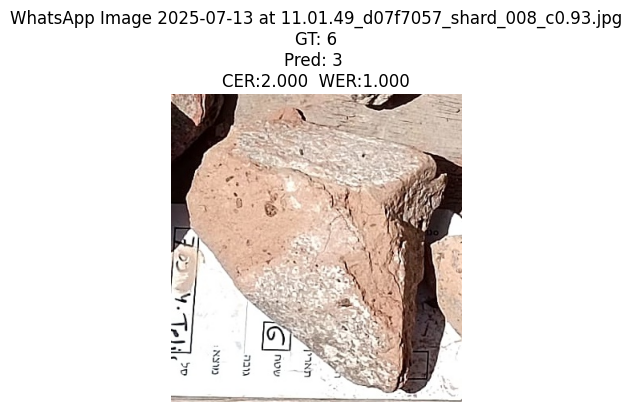

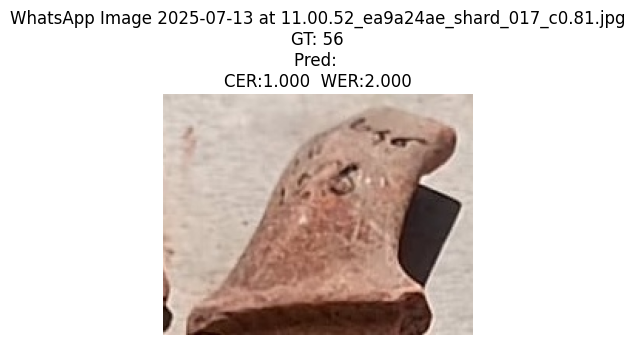

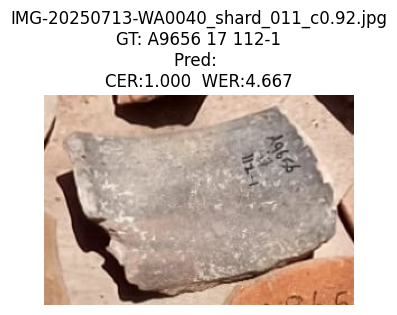

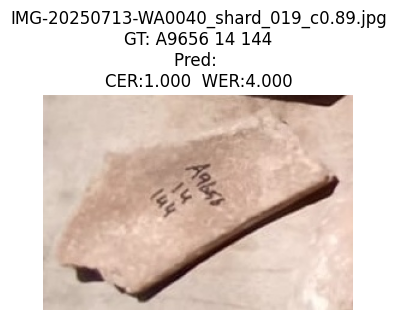

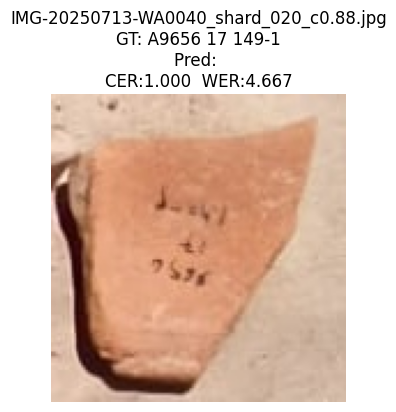

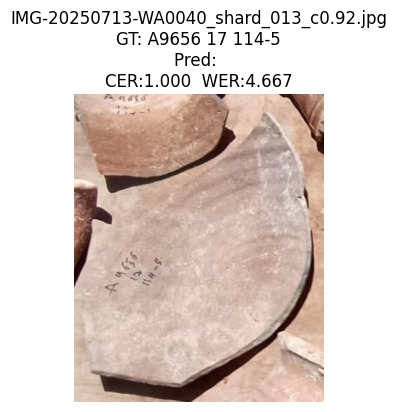

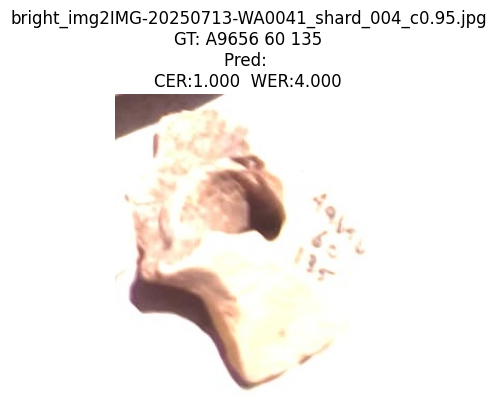

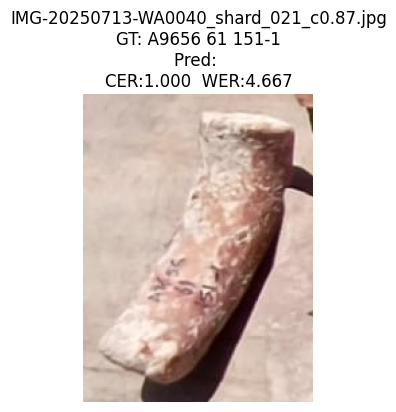

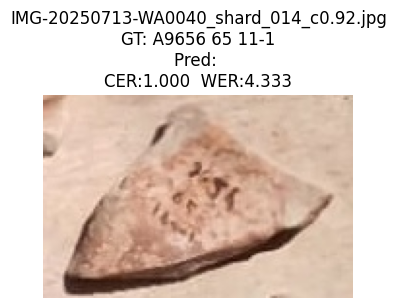

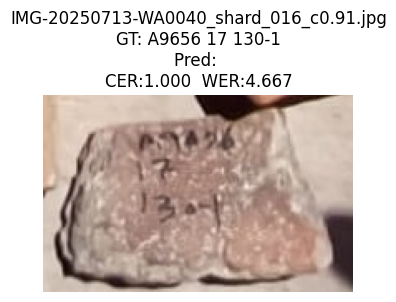

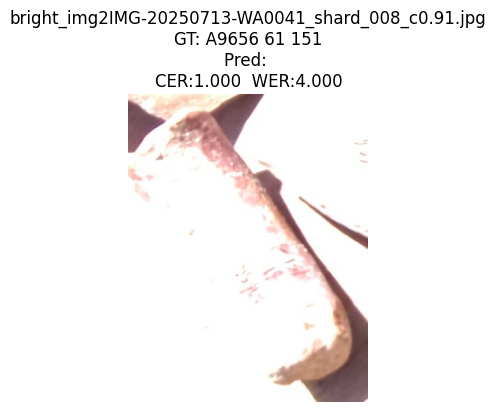

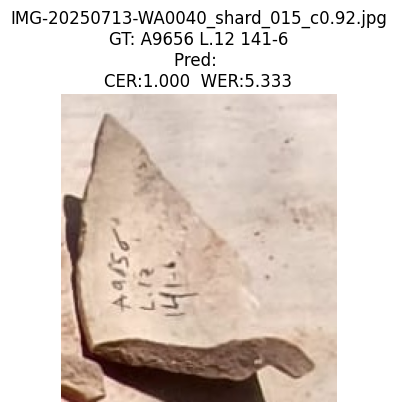

In [30]:
# === Notebook end: show results inline ===
import os, cv2, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import display

assert 'df' in globals() and len(df) > 0, "df ריק – ודאי שההרצה יצרה תוצאות."

# 1) Summary (compact)
print("Summary")
print("--------")
print(f"images:         {summary.get('n_images')}")
if summary.get('avg_CER') is not None:        print(f"avg CER:        {summary['avg_CER']:.4f}")
if summary.get('avg_WER') is not None:        print(f"avg WER:        {summary['avg_WER']:.4f}")
if summary.get('avg_levenshtein') is not None:print(f"avg Levenshtein:{summary['avg_levenshtein']:.3f}")
if summary.get('avg_latency_ms') is not None: print(f"avg latency ms: {summary['avg_latency_ms']:.1f}")

# 2) Full table (styled, scrollable)
view = df.copy()
cols_order = [c for c in ['filename','gt_text','pred_text','cer','wer','latency_ms','chars_gt','chars_pred'] if c in view.columns]
view = view[cols_order]

styled = (
    view.sort_values('cer', ascending=False)
        .style.format({'cer':'{:.3f}','wer':'{:.3f}','latency_ms':'{:.0f}'})
        .background_gradient(subset=['cer','wer'], cmap='Reds')
        .bar(subset=['chars_gt','chars_pred'], color='#bbbbbb')
)
display(styled)

# 3) Visual “worst 12” with images (optional)
K = 12
worst = view.sort_values('cer', ascending=False).head(K)
for _, r in worst.iterrows():
    img_path = os.path.join(IMAGES_DIR, r['filename'])
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4))
    plt.imshow(img); plt.axis('off')
    plt.title(f"{r['filename']}\nGT: {r['gt_text']}\nPred: {r['pred_text']}\nCER:{r['cer']:.3f}  WER:{r['wer']:.3f}")
    plt.show()
